<a href="https://colab.research.google.com/github/EmilienPelosse/MVPA/blob/main/MindReading_Report1_Emil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 62.4 MB/s eta 0:00:00


# Structural Imaging Assignment
For this assignment, you will work with MRI data from approximately 900 participants from the Amsterdam Open MRI Collection (AOMIC). The dataset is described in detail here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. Sci Data 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

FreeSurfer preprocessing has already been completed. You will receive:

- A CSV table with FreeSurfer-derived measures (cortical thickness, surface area, curvature, subcortical volumes)
- A table with demographic information (age, biological sex)
- A data dictionary explaining each column

### Your Task
Build a classification model to predict biological sex from brain structure. Specifically:
- Identify which brain measures contribute most to classification
- Quantify effect sizes and classification performance
- Characterise the degree of overlap between groups
- Discuss what your findings reveal about sex differences in brain structure

For this assignment, you will use logistic regression to classify sex from brain structure. Logistic regression is appropriate for binary classification, computationally efficient, and provides interpretable coefficients indicating which features contribute most to classification.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas. You can also refer to the notebooks from the lab practicals, especially Lab 4 on predicting age from brain structure.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [2]:
# ------- Leave this code as is -----------
### Loading the data

import os
import pandas as pd
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Download required data files
for url, name in zip([
        "https://www.dropbox.com/scl/fi/kssezv0bic0asdlug4vtn/demographic_data.csv?rlkey=rn3zs0ggjcprkcmec54uy6s5s&dl=1",
        "https://www.dropbox.com/scl/fi/ypa33lzz0mlx8cswz9nej/morphology_data.csv?rlkey=awl906mvp10pofv6hjilfzl8e&dl=1"
    ],
    [
        "demographic_data.csv",
        "morphology_data.csv"
    ]):

    download_file(url, name)

demography_df = pd.read_csv("demographic_data.csv")
morphology_df = pd.read_csv("morphology_data.csv")

Saved as demographic_data.csv
Saved as morphology_data.csv


### Part 1: Code Implementation (30%)
Implement your proposed analysis with clear structure

Include comments or markdown cells explaining:
- What each code section does
- Why you made specific methodological choices (e.g., "Using 5-fold CV to balance bias-variance tradeoff")
- Any assumptions or decisions about data handling
- Ensure code runs without errors

You can use the code below as a starting point.

In [8]:
# The demographic data is stored a Pandas dataframe called `demography_df`
demography_df.head()

# The morphology data is stored a Pandas dataframe called `morphology_df`
morphology_df.head()

# Merging both files to ensure that the data is aligned correctly
data_df = pd.merge(demography_df, morphology_df, on="participant_id")

# Extracting X and y for the classification task
# Using only cortical thickness measures and making sure to remove the
# MeanThickness column (not an independent feature)
thickness_cols = [col for col in data_df.columns
                  if 'thickness' in col and 'MeanThickness' not in col]
print(f"Number of features: {len(thickness_cols)}")
print(thickness_cols)
X = data_df[thickness_cols].values
y = data_df[['sex']].values

# Recoding the target variable to binary (0 and 1)
y = (y == 'male').astype(int).ravel()  # male = 1

# Checking the shapes of X and y
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Splitting the data into training and test sets for the finale validation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Z-scores all features so they have mean=0 and SD=1. fit_transform on X_train
# learns the mean and SD from the training data only, then applies it. transform
# on X_test applies those same training statistics to the test set, crucially
# without learning anything new from it. This prevents data leakage.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Training set X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test set X shape: {X_test.shape}, y shape: {y_test.shape}')

import numpy as np

# Identify outliers in training set (>3 SD — already z-scored so threshold directly)
outlier_mask = (np.abs(X_train) > 3).any(axis=1)
print(f"Outliers found in training set: {outlier_mask.sum()} out of {len(X_train)}")

X_train_clean = X_train[~outlier_mask]
y_train_clean = y_train[~outlier_mask]
print(f"Training samples after removal: {X_train_clean.shape[0]}")

# Defining the logistic regression model
# Note: I'm using L2 regularisation and the liblinear solver – you can use different settings depending on your research
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', random_state=42)

# Setting up 5-fold cross-validation for parameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
}

print("=== WITH OUTLIERS ===")
# Performing grid search with 5-fold cross-validation to find the best hyperparameters
# Note: I use 'roc_auc' as the scoring metric to balance sensitivity and specificity
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Best hyperparameters from grid search
best_params = grid_search.best_params_
print(f'Best hyperparameters: {best_params}')

# Evaluating the best model on the training set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_train)
y_proba = best_model.predict_proba(X_train)[:, 1]  # Probability of being in the male class

from sklearn.metrics import balanced_accuracy_score
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_train, y_proba):.4f}")

# Evaluating the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilityof being in the male class
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
n = len(y_test)
ci = 1.96 * np.sqrt((acc * (1 - acc)) / n)
print(f"Accuracy 95% CI: [{acc - ci:.3f}, {acc + ci:.3f}]")


print("=== WITHOUT OUTLIERS ===")
grid_search.fit(X_train_clean, y_train_clean)

# Best hyperparameters from grid search
best_params = grid_search.best_params_
print(f'Best hyperparameters: {best_params}')

# Evaluating the best model on the training set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_train_clean)
y_proba = best_model.predict_proba(X_train_clean)[:, 1]  # Probability of being in the male class

from sklearn.metrics import balanced_accuracy_score
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train_clean, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_train_clean, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train_clean, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_train_clean, y_proba):.4f}")

# Evaluating the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilityof being in the male class
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Number of features: 68
['lh_bankssts_thickness', 'lh_caudalanteriorcingulate_thickness', 'lh_caudalmiddlefrontal_thickness', 'lh_cuneus_thickness', 'lh_entorhinal_thickness', 'lh_fusiform_thickness', 'lh_inferiorparietal_thickness', 'lh_inferiortemporal_thickness', 'lh_isthmuscingulate_thickness', 'lh_lateraloccipital_thickness', 'lh_lateralorbitofrontal_thickness', 'lh_lingual_thickness', 'lh_medialorbitofrontal_thickness', 'lh_middletemporal_thickness', 'lh_parahippocampal_thickness', 'lh_paracentral_thickness', 'lh_parsopercularis_thickness', 'lh_parsorbitalis_thickness', 'lh_parstriangularis_thickness', 'lh_pericalcarine_thickness', 'lh_postcentral_thickness', 'lh_posteriorcingulate_thickness', 'lh_precentral_thickness', 'lh_precuneus_thickness', 'lh_rostralanteriorcingulate_thickness', 'lh_rostralmiddlefrontal_thickness', 'lh_superiorfrontal_thickness', 'lh_superiorparietal_thickness', 'lh_superiortemporal_thickness', 'lh_supramarginal_thickness', 'lh_frontalpole_thickness', 'lh_t

### Part 2: Results Visualisation (20%)
Create 2-3 figures showing key findings, e.g.:
- Classification performance (e.g., confusion matrix, ROC curve, accuracy with confidence intervals)
- Feature importance or effect sizes (e.g., which regions contribute most)
- Distribution overlap (e.g., histograms or scatter plots showing individual variation)

Include clear figure captions explaining what is shown

Below are some examples to get you started, but please modify or create your own visualisations that best illustrate your findings.

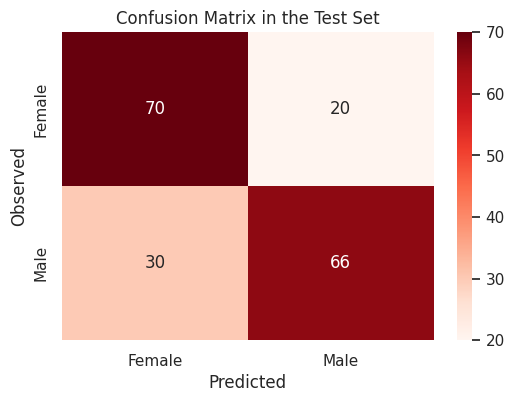

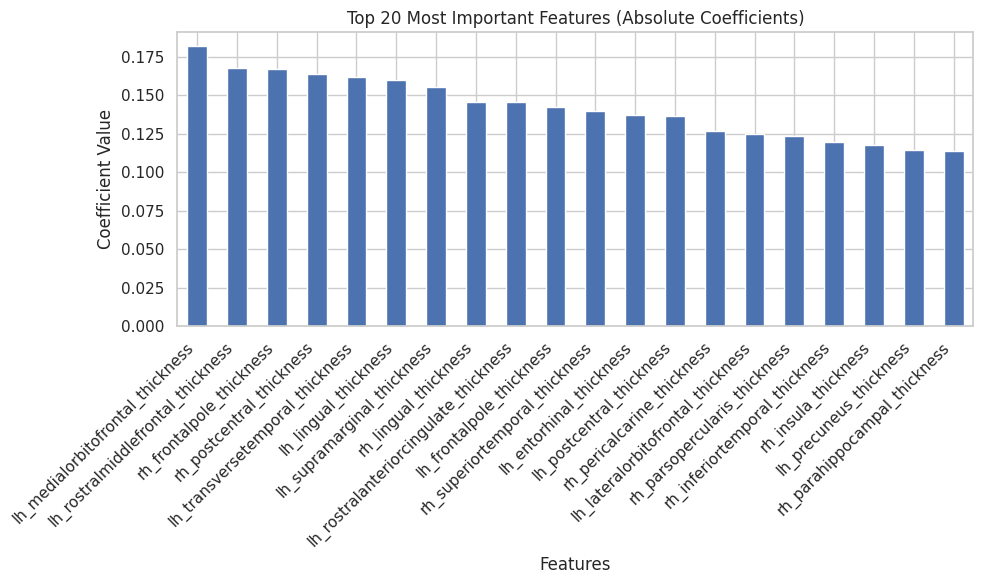

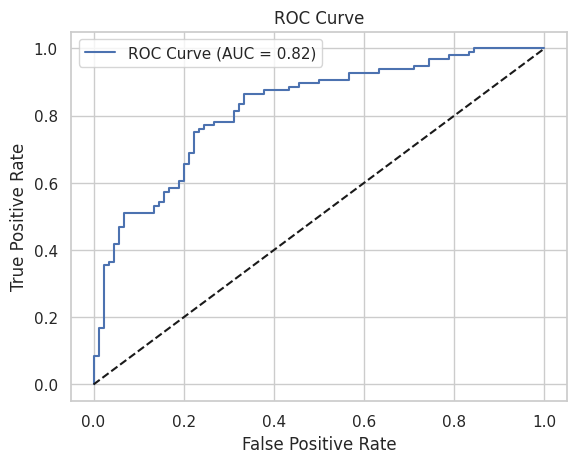

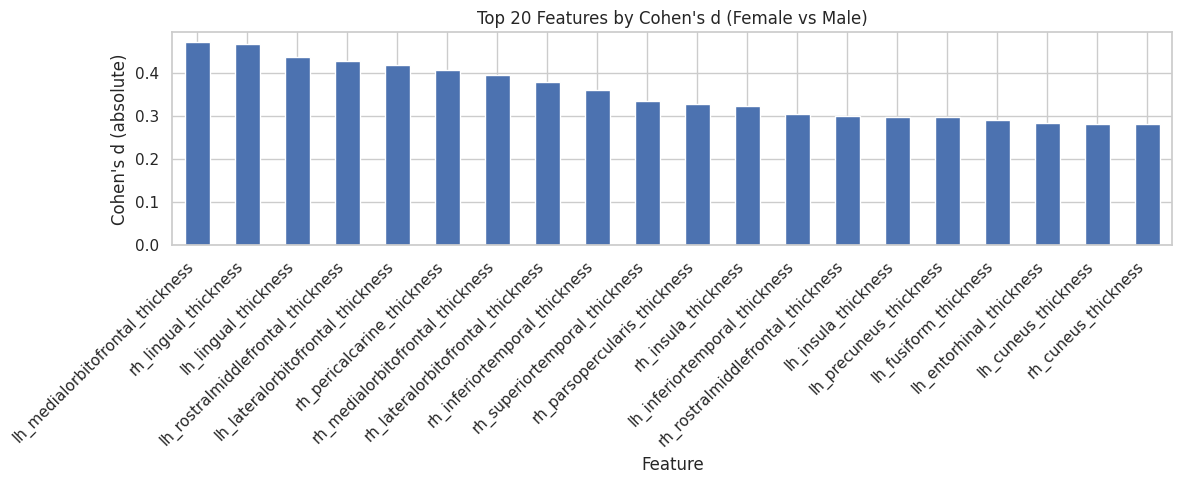

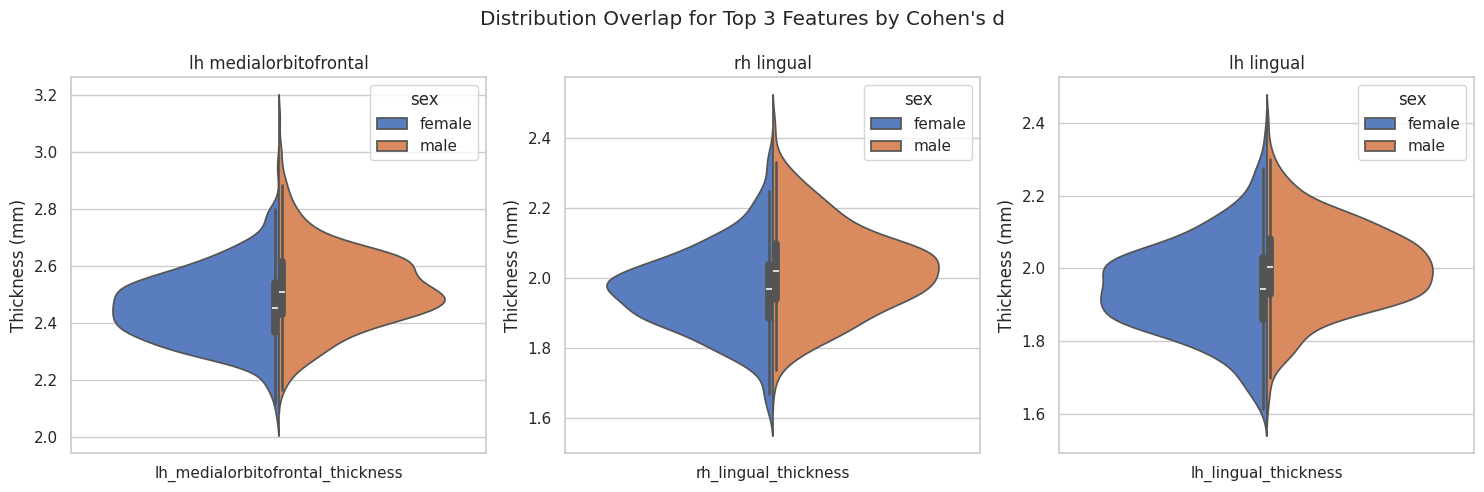

Top 20 Features: β, Odds Ratio, Cohen's d, FDR-corrected p-values


,Feature,β (coef),Odds Ratio,Cohen's d,p (uncorr),p (FDR-corr)
0,lh medialorbitofrontal,0.1818,1.1994,0.4708,3.9221e-10,1.6040e-08
1,lh rostralmiddlefrontal,0.1679,1.1829,0.4267,9.7789e-09,1.6624e-07
2,rh frontalpole,-0.1672,0.8460,-0.1900,9.9360e-03,2.1795e-02
3,rh postcentral,-0.1641,0.8486,-0.1540,3.5901e-02,6.7813e-02
4,lh transversetemporal,-0.1621,0.8504,-0.0802,2.7451e-01,3.5221e-01
5,lh lingual,0.1601,1.1737,0.4367,3.5929e-09,8.1440e-08
6,lh supramarginal,-0.1556,0.8559,-0.0433,5.5735e-01,6.2130e-01
7,rh lingual,0.1458,1.1569,0.4662,4.7176e-10,1.6040e-08
8,lh rostralanteriorcingulate,-0.1457,0.8645,-0.0548,4.5459e-01,5.2393e-01
9,lh frontalpole,-0.1421,0.8675,-0.1205,1.0206e-01,1.5773e-01



Full table saved to feature_importance_table.csv


In [16]:
# I choose to keep the ouliers. The differences are very small.
# Removing 89 participants barely changed anything, it suggests the outliers
# weren't unduly influencing the model, and the results are robust either way.

# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix in the Test Set')
plt.xlabel('Predicted')
plt.ylabel('Observed')

# Plot the 20 most important features based on the absolute coefficients of the logistic regression model
feature_importance = pd.Series(best_model.coef_[0], index=thickness_cols)
plt.figure(figsize=(10, 6))
feature_importance.abs().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Top 20 Most Important Features (Absolute Coefficients)')
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Plot the ROC-Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get predicted probabilities from the best model
y_probs = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# 3. Plot
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
plt.show()

# Cohen's d Curve
from numpy import std, mean, sqrt
import pandas as pd

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (mean(x) - mean(y)) / sqrt(((nx-1)*std(x, ddof=1) ** 2 + (ny-1)*std(y, ddof=1) ** 2) / dof)

# Split training data into male and female groups
X_male = X_train[y_train == 1]
X_female = X_train[y_train == 0]

# Compute Cohen's d for each feature
d_values = [cohen_d(X_male[:, i], X_female[:, i]) for i in range(X_train.shape[1])]
d_series = pd.Series(d_values, index=thickness_cols)

# Plot sorted by absolute d
d_series.abs().sort_values(ascending=False).head(20).plot(kind='bar', figsize=(12, 5))
plt.title('Top 20 Features by Cohen\'s d (Female vs Male)')
plt.ylabel('Cohen\'s d (absolute)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Density/violin plot
import seaborn as sns
import pandas as pd

# Get top 3 features by absolute Cohen's d
top_features = d_series.abs().sort_values(ascending=False).head(3).index.tolist()

# Build a dataframe with raw (unscaled) values and sex labels
plot_df = data_df[top_features + ['sex']].copy()

# Melt into long format for seaborn
plot_df_long = plot_df.melt(id_vars='sex', value_vars=top_features,
                             var_name='Feature', value_name='Thickness (mm)')

# Plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(top_features):
    subset = plot_df_long[plot_df_long['Feature'] == feature]
    sns.violinplot(x='Feature', y='Thickness (mm)', hue='sex',
                   data=subset, palette='muted', split=True, ax=axes[i])
    axes[i].set_title(feature.replace('_thickness', '').replace('_', ' '))
    axes[i].set_xlabel('')

plt.suptitle('Distribution Overlap for Top 3 Features by Cohen\'s d')
plt.tight_layout()
plt.show()


import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- Coefficients and Odds Ratios from logistic regression ---
coef = best_model.coef_[0]
odds_ratios = np.exp(coef)

# --- P-values via independent samples t-test (two-sided) on training data ---
p_values = []
for i in range(X_train.shape[1]):
    _, p = stats.ttest_ind(X_male[:, i], X_female[:, i], equal_var=False)  # Welch's t-test
    p_values.append(p)

# --- FDR correction (Benjamini-Hochberg) ---
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# --- Assemble the table ---
results_df = pd.DataFrame({
    'Feature':      thickness_cols,
    'β (coef)':     coef,
    'Odds Ratio':   odds_ratios,
    "Cohen's d":    d_series.values,
    'p (uncorr)':   p_values,
    'p (FDR-corr)': p_corrected,
})

# Sort by absolute coefficient value descending
results_df['|β|'] = results_df['β (coef)'].abs()
results_df = results_df.sort_values('|β|', ascending=False).drop(columns='|β|')
results_df = results_df.reset_index(drop=True)

# --- Display top 20 ---
top20 = results_df.head(20).copy()

# Format for readability
top20['β (coef)']     = top20['β (coef)'].map('{:.4f}'.format)
top20['Odds Ratio']   = top20['Odds Ratio'].map('{:.4f}'.format)
top20["Cohen's d"]    = top20["Cohen's d"].map('{:.4f}'.format)
top20['p (uncorr)']   = top20['p (uncorr)'].map('{:.4e}'.format)
top20['p (FDR-corr)'] = top20['p (FDR-corr)'].map('{:.4e}'.format)

# Clean up feature names for display
top20['Feature'] = top20['Feature'].str.replace('_thickness', '', regex=False)\
                                   .str.replace('_', ' ', regex=False)

print("Top 20 Features: β, Odds Ratio, Cohen's d, FDR-corrected p-values")
print("=" * 80)
display(top20.reset_index(drop=True))

# --- Optional: save to CSV ---
results_df.to_csv('feature_importance_table.csv', index=False)
print("\nFull table saved to feature_importance_table.csv")

### 3. Interpretation and Reflection (50%)

Interpretation (~400-500 words):
- What is your classification accuracy? Is this high or low, and compared to what?
- Which brain measures show the largest sex differences?
- How much overlap exists between groups? What proportion of variance is explained by sex?
- What do your results suggest about structural sex differences in the brain?

Reflection (~600-800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about neuroimaging analysis?

*You can write your interpretation and reflection in this markdown cell. Feel free to structure it with subheadings, bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*